# Análisis de Desigualdades Regionales en Hospitalización de Alta Complejidad
## GRD Sistema Público de Salud de Chile FONASA (2023–2024)


**Integrantes del grupo:** Lukas Garrido, Cristobal Ramirez



---
## Carga de Librerías y Configuración Inicial


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas
import geodatasets
import warnings
import contextily as ctx
from adjustText import adjust_text

warnings.filterwarnings('ignore')

# Configuración estética global de matplotlib
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})
PALETTE = 'Blues_r'
COLOR_MAIN = '#1f77b4'
COLOR_SEC  = '#d62728'

---
## Carga y Preprocesamiento de Datos

### Carga de los Datos GRD (2023 y 2024)

Se cargan los archivos GRD de ambos años. Las columnas de fecha se parsean automáticamente y las columnas numéricas con valores no estándar se convierten con `errors='coerce'`, esto quiere decir que pasan a NaN.


In [2]:

# CARGA GRD 2024

GRD_2024 = pd.read_csv(
    'BDDs/GRD_PUBLICO_2024.csv',
    sep='|', encoding='latin-1', low_memory=False,
    parse_dates=['FECHA_NACIMIENTO', 'FECHA_INGRESO', 'FECHAALTA'],
    dayfirst=True, date_format='%d/%m/%Y'
)

# Conversión de columnas numéricas con valores no estándar
for col in ['IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'IR_29301_COD_GRD']:
    GRD_2024[col] = pd.to_numeric(GRD_2024[col], errors='coerce')
GRD_2024['IR_29301_COD_GRD'] = GRD_2024['IR_29301_COD_GRD'].fillna(0).astype(str)



In [3]:

GRD_2023 = pd.read_csv(
    'BDDs/GRD_PUBLICO_2023.txt',
    sep='|', encoding='utf-16', low_memory=False, decimal=',',
    parse_dates=['FECHA_NACIMIENTO', 'FECHA_INGRESO', 'FECHAALTA'],
    dayfirst=True, date_format='%d/%m/%Y'
)

for col in ['IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'IR_29301_COD_GRD']:
    GRD_2023[col] = pd.to_numeric(GRD_2023[col], errors='coerce')
GRD_2023['IR_29301_COD_GRD'] = GRD_2023['IR_29301_COD_GRD'].fillna(0).astype(str)



### Carga de Diccionarios y Establecimientos

Cargamos los diccionarios de hospitales, GRD, severidad y mortalidad, además del dataset de establecimientos de salud que incluye información geográfica y de clasificación de Complejidad (encontrado [aquí](https://datos.gob.cl/dataset/establecimientos-de-salud-vigentes/resource/2c44d782-3365-44e3-aefb-2c8b8363a1bc))


In [ ]:
# Diccionarios
hospitales  = pd.read_csv('BDDs/Hospitales.csv', sep='|', encoding='utf-8',
                           header=None, names=['COD_HOSPITAL', 'NOMBRE_HOSPITAL'])
irgrd       = pd.read_csv('BDDs/IR-GRD.csv',    sep='|',
                           header=None, names=['COD_GRD', 'DESCRIPCION_GRD'])
mortalidad  = pd.read_csv('BDDs/Mortalidad.csv', sep='|', encoding='utf-8',
                           header=None, names=['CODIGO', 'SEVERIDAD'])
severidad   = pd.read_csv('BDDs/Severidad.csv',  sep='|', encoding='utf-8',
                           header=None, names=['CODIGO', 'MORTALIDAD'])

# Limpieza del código GRD para el merge
irgrd['COD_GRD'] = irgrd['COD_GRD'].astype(str)
irgrd['GRD_CODIGO_LIMPIO'] = irgrd['COD_GRD'].str.extract(r'(\d+)')


# Establecimientos de alta complejidad
establecimientos   = pd.read_csv('BDDs/establecimientos.csv', sep=';', low_memory=False)
establecimientosAlta = establecimientos[
    establecimientos['NivelComplejidadEstabGlosa'] == 'Alta Complejidad'
]

###  Integración de Datasets

Unión de los datos GRD de ambos años con los diccionarios de hospitales, GRD, severidad y mortalidad. 


In [5]:

def merge_grd(df):
    # Agrega columnas descriptivas (hospital, GRD, severidad, mortalidad) al GRD.
    df = df.merge(hospitales, on='COD_HOSPITAL', how='left')
    df['GRD_CODIGO_LIMPIO'] = df['IR_29301_COD_GRD'].str.extract(r'(\d+)')
    df = df.merge(irgrd[['GRD_CODIGO_LIMPIO', 'DESCRIPCION_GRD']], on='GRD_CODIGO_LIMPIO', how='left')
    df = df.merge(severidad, left_on='IR_29301_SEVERIDAD', right_on='CODIGO', how='left')
    df = df.merge(mortalidad, left_on='IR_29301_MORTALIDAD', right_on='CODIGO', how='left', suffixes=('_sev', '_mor'))
    return df



GRD_2023_new = merge_grd(GRD_2023)
GRD_2024_new = merge_grd(GRD_2024)


# Filtro de hospitales de alta complejidad (solo hospitales con alta complejidad en ambos años)

GRD_2023_ALTA = GRD_2023_new[GRD_2023_new['COD_HOSPITAL'].isin(establecimientosAlta['EstablecimientoCodigo'])]
GRD_2024_ALTA = GRD_2024_new[GRD_2024_new['COD_HOSPITAL'].isin(establecimientosAlta['EstablecimientoCodigo'])]

# unión de ambos años y merge con datos de establecimientos para obtener latitud, longitud y comuna de cada hospital de alta complejidad
# ============================================================
GRD_ALTA = pd.concat([GRD_2023_ALTA, GRD_2024_ALTA], ignore_index=True)
GRD_ALTA = GRD_ALTA.merge(
    establecimientosAlta[['EstablecimientoCodigo', 'Latitud', 'Longitud', 'ComunaCodigo', 'ComunaGlosa']],
    left_on='COD_HOSPITAL', right_on='EstablecimientoCodigo', how='left'
)
GRD_ALTA.drop(columns=['EstablecimientoCodigo'], inplace=True)


---
##  Análisis Exploratorio de Datos (EDA)

###  Limpieza de Datos: Valores Ausentes y Tipos


In [6]:

# Columnas clave para el análisis
cols_clave = ['PROVINCIA', 'COMUNA', 'NOMBRE_HOSPITAL', 'SERVICIO_SALUD',
              'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD', 'SEVERIDAD', 'MORTALIDAD', 'Latitud', 'Longitud']

nulos = GRD_ALTA[cols_clave].isnull().sum()
pct   = (nulos / len(GRD_ALTA) * 100)

resumen_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct})
print('Valores ausentes en columnas clave:')
print(resumen_nulos[resumen_nulos['Nulos'] > 0].to_string())
print(f'\nTotal de registros: {len(GRD_ALTA):,}')
print(" Debido al poco porcentaje de valores ausentes en columnas clave, se procederá sin eliminar registros.")

Valores ausentes en columnas clave:
                     Nulos   % Nulos
IR_29301_SEVERIDAD      45  0.002264
IR_29301_MORTALIDAD     45  0.002264
SEVERIDAD               45  0.002264
MORTALIDAD              45  0.002264

Total de registros: 1,987,858
 Debido al poco porcentaje de valores ausentes en columnas clave, se procederá sin eliminar registros.


In [7]:

# Calculando dias de estancia si existen columnas de fecha


if 'FECHA_INGRESO' in GRD_ALTA.columns and 'FECHAALTA' in GRD_ALTA.columns:
    GRD_ALTA['FECHA_INGRESO'] = pd.to_datetime(GRD_ALTA['FECHA_INGRESO'], errors='coerce')
    GRD_ALTA['FECHAALTA'] = pd.to_datetime(GRD_ALTA['FECHAALTA'], errors='coerce')
    GRD_ALTA['ESTANCIA_DIAS'] = (GRD_ALTA['FECHAALTA'] - GRD_ALTA['FECHA_INGRESO']).dt.days
    GRD_ALTA.loc[GRD_ALTA['ESTANCIA_DIAS'] < 0, 'ESTANCIA_DIAS'] = np.nan
    print('Columna ESTANCIA_DIAS calculada.')


Columna ESTANCIA_DIAS calculada.


### Estadísticas Descriptivas

Calculamos media, mediana, desviación estándar y percentiles de las variables numéricas más relevantes.


In [8]:
# Estadísticas descriptivas básicas
# Estadisticas numericas clave
vars_numericas = ['IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD','ESTANCIA_DIAS']
print("Estadísticas descriptivas de variables numéricas clave:")
display(GRD_ALTA[vars_numericas].describe().T)


Estadísticas descriptivas de variables numéricas clave:


,count,mean,std,min,25%,50%,75%,max
IR_29301_SEVERIDAD,1987813.0,1.455777,1.012708,0.0,1.0,1.0,2.0,3.0
IR_29301_MORTALIDAD,1987813.0,1.309578,0.963004,0.0,1.0,1.0,2.0,3.0
ESTANCIA_DIAS,211157.0,110.910796,85.942567,0.0,33.0,93.0,177.0,665.0


---
## Visualizaciones

### Casos por Provincia: Procedencia de los Pacientes

Este gráfico muestra las 10 provincias con más pacientes hospitalizados en establecimientos de alta complejidad, respondiendo a la pregunta sobre el origen geográfico de los casos.


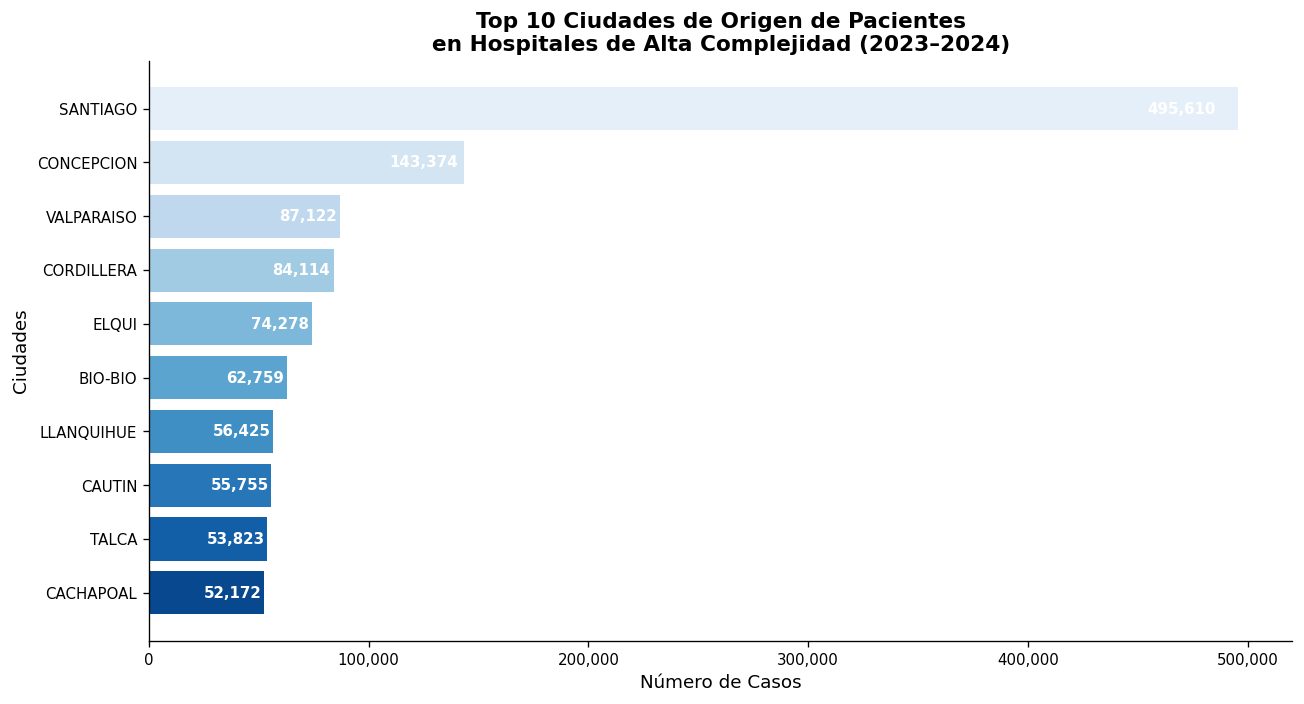


Nota: La provincia de Santiago concentra la mayor cantidad de pacientes,
      lo que refleja tanto la mayor población como la concentración de hospitales.


In [ ]:

top_provincias_origen = GRD_ALTA['PROVINCIA'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_provincias_origen.index[::-1],
    top_provincias_origen.values[::-1],
    color=sns.color_palette(PALETTE, 10)
)

# Etiquetas de valor dentro de las barras
for bar, val in zip(bars, top_provincias_origen.values[::-1]):
    ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='right', color='white', fontweight='bold', fontsize=9)

ax.set_title('Top 10 Ciudades de Origen de Pacientes\nen Hospitales de Alta Complejidad (2023–2024)', fontweight='bold')
ax.set_xlabel('Número de Casos')
ax.set_ylabel('Ciudades')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nNota: La provincia de Santiago concentra la mayor cantidad de pacientes,')
print('      lo que refleja tanto la mayor población como la concentración de hospitales.')

### Distribución de Casos por Servicio de Salud

Agrupamos los casos por Servicio de Salud para identificar cuáles concentran más hospitalizaciones de alta complejidad.


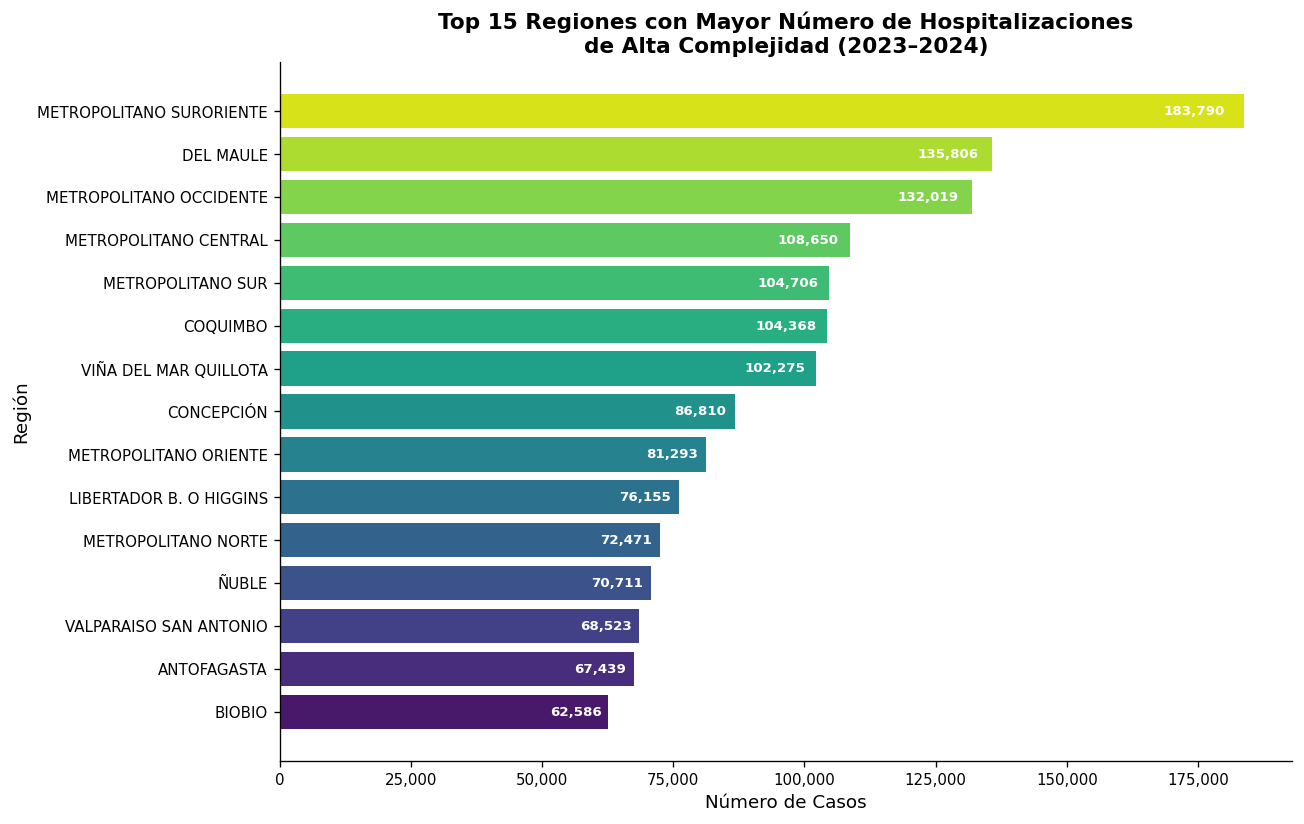

In [ ]:

top_servicios = GRD_ALTA['SERVICIO_SALUD'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    top_servicios.index[::-1],
    top_servicios.values[::-1],
    color=sns.color_palette('viridis', 15)
)

for bar, val in zip(bars, top_servicios.values[::-1]):
    ax.text(bar.get_width() * 0.98, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='right', color='white', fontweight='bold', fontsize=8)

ax.set_title('Top 15 Regiones con Mayor Número de Hospitalizaciones\nde Alta Complejidad (2023–2024)', fontweight='bold')
ax.set_xlabel('Número de Casos')
ax.set_ylabel('Región')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Histograma: Distribución de la Estancia Hospitalaria


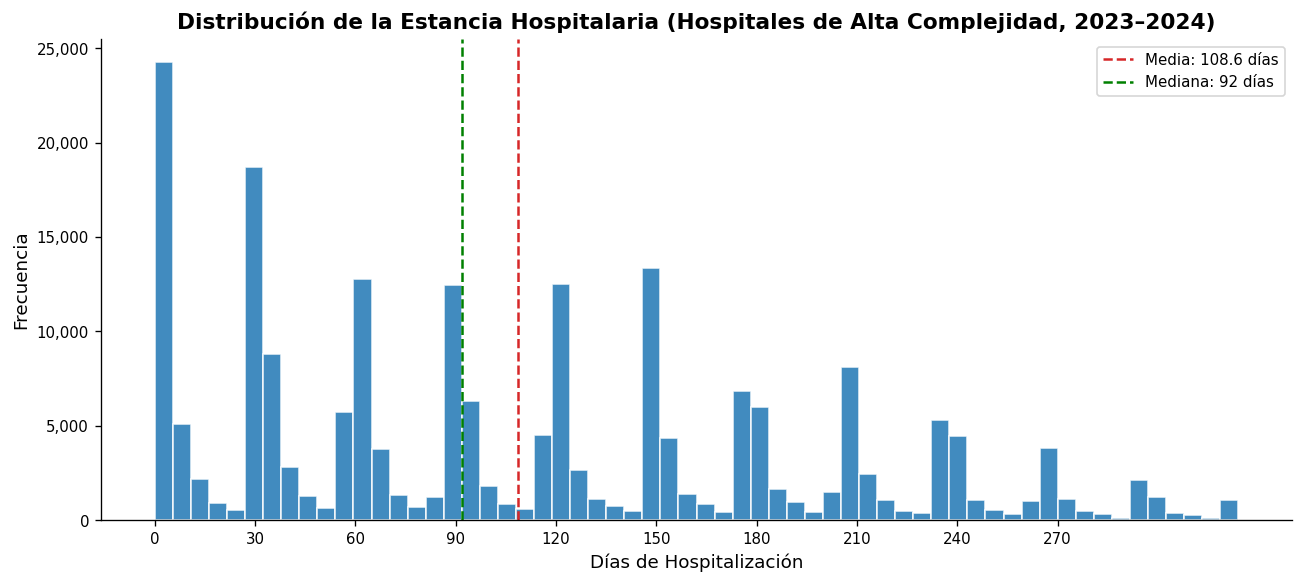

In [ ]:

if 'ESTANCIA_DIAS' in GRD_ALTA.columns:
    estancia_valida = GRD_ALTA['ESTANCIA_DIAS'].dropna()
    estancia_valida = estancia_valida[estancia_valida <= estancia_valida.quantile(0.99)]  # Sin outliers extremos

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.hist(estancia_valida, bins=60, color=COLOR_MAIN, edgecolor='white', alpha=0.85)
    media_est = estancia_valida.mean()
    mediana_est = estancia_valida.median()
    ax.axvline(media_est,   color=COLOR_SEC, linestyle='--', lw=1.5, label=f'Media: {media_est:.1f} días')
    ax.axvline(mediana_est, color='green',   linestyle='--', lw=1.5, label=f'Mediana: {mediana_est:.0f} días')
    ax.set_title('Distribución de la Estancia Hospitalaria (Hospitales de Alta Complejidad, 2023–2024)',
                 fontweight='bold')
    ax.set_xlabel('Días de Hospitalización')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticks(np.arange(0,300, 30))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.tight_layout()
    plt.show()
else:
    print('Columna ESTANCIA_DIAS no disponible.')

### Mapa Geoespacial: Concentración de Hospitalizaciones por Hospital

Graficamos los hospitales de alta complejidad sobre el mapa de Chile. El tamaño de cada punto es proporcional al número de hospitalizaciones registradas, evidenciando la concentración geográfica.


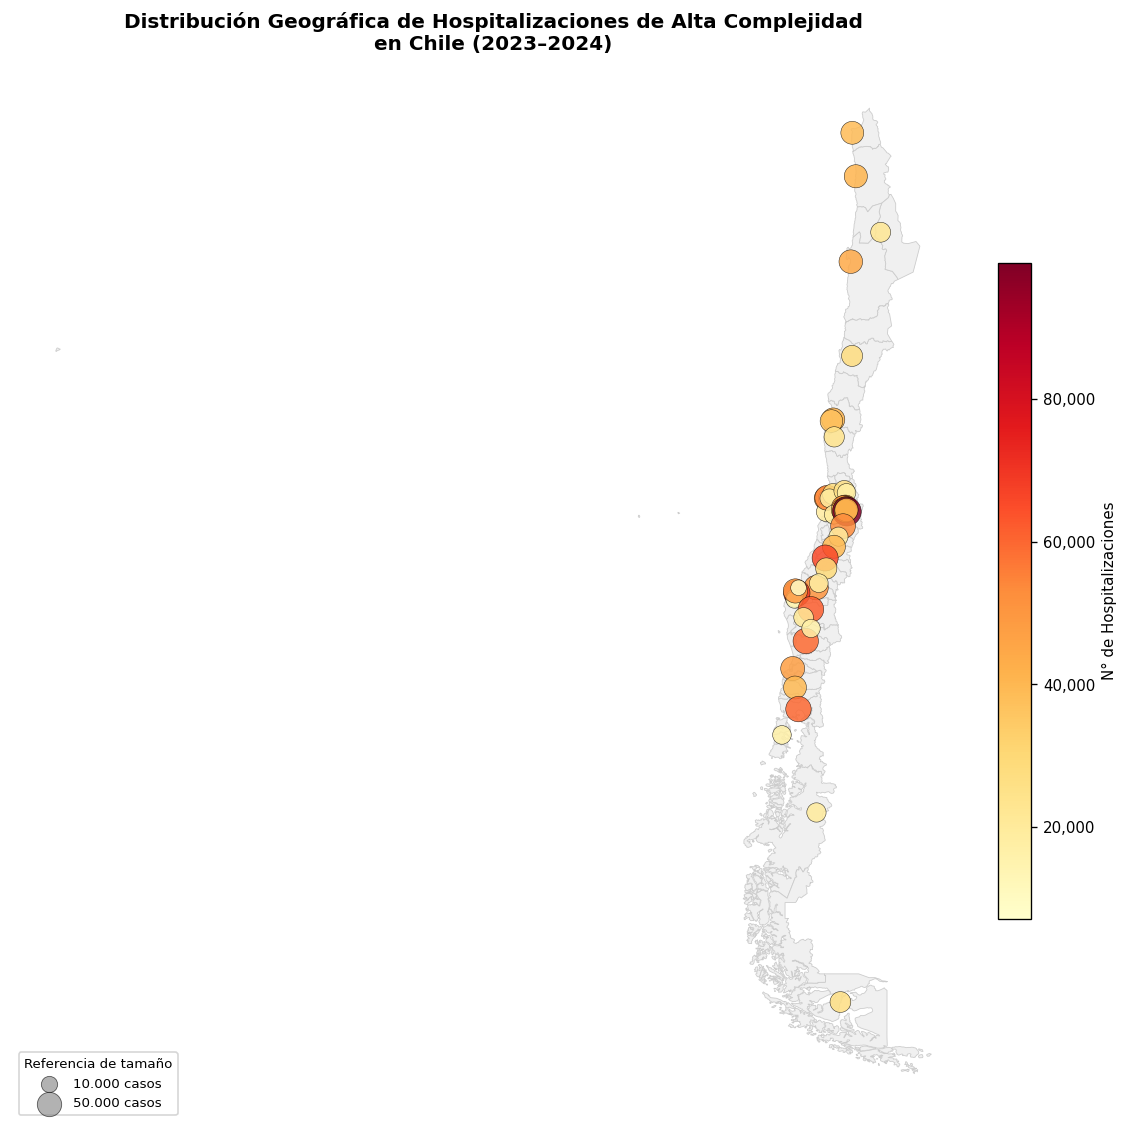


Hospitales graficados: 58
Hospital con más hospitalizaciones:  Complejo Hospitalario Dr. Sótero del Río (Santiago, Puente Alto) (99,064 casos)


In [ ]:


# Contar casos por hospital y obtener sus coordenadas
casos_hospital = (
    GRD_ALTA.groupby('COD_HOSPITAL')
    .agg(N_CASOS=('COD_HOSPITAL', 'count'),
         NOMBRE=('NOMBRE_HOSPITAL', 'first'),
         Latitud=('Latitud', 'first'),
         Longitud=('Longitud', 'first'),
         CIUDAD = ('ComunaGlosa', 'first'))
    .dropna(subset=['Latitud', 'Longitud'])
    .reset_index()
)
# Crear GeoDataFrame
geometry = geopandas.points_from_xy(casos_hospital['Longitud'], casos_hospital['Latitud'])
gdf_hospitales = geopandas.GeoDataFrame(casos_hospital, geometry=geometry, crs='EPSG:4326')

# Escala de tamaño: raíz cuadrada para que los puntos no sean demasiado grandes
gdf_hospitales['MARKERSIZE'] = (gdf_hospitales['N_CASOS'] / gdf_hospitales['N_CASOS'].max()) ** 0.5 * 300

# Cargar mapa base de Chile
chile = geopandas.read_file(geodatasets.get_path('geoda.chile_labor'))

fig, ax = plt.subplots(figsize=(10, 14))
chile.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5)

scatter = gdf_hospitales.plot(
    ax=ax,
    column='N_CASOS',
    cmap='YlOrRd',
    markersize=gdf_hospitales['MARKERSIZE'],
    legend=False,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.3
)

# Colorbar manual
sm = plt.cm.ScalarMappable(cmap='YlOrRd',
                            norm=plt.Normalize(vmin=gdf_hospitales['N_CASOS'].min(),
                                               vmax=gdf_hospitales['N_CASOS'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('N° de Hospitalizaciones', fontsize=9)
cbar.ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax.set_title('Distribución Geográfica de Hospitalizaciones de Alta Complejidad\nen Chile (2023–2024)',
             fontsize=12, fontweight='bold')
ax.set_axis_off()

# Leyenda de tamaño
for n, label in [(10000, '10.000'), (50000, '50.000'), (100000, '100.000')]:
    if n <= gdf_hospitales['N_CASOS'].max():
        size = (n / gdf_hospitales['N_CASOS'].max()) ** 0.5 * 300
        ax.scatter([], [], s=size, c='gray', alpha=0.6, edgecolor='black', lw=0.5,
                   label=f'{label} casos')
ax.legend(title='Referencia de tamaño', loc='lower left', fontsize=8, title_fontsize=8,
          framealpha=0.8)


# 1. Filtramos Santiago como ya vimos
ciudades = (gdf_hospitales
                .sort_values('N_CASOS', ascending=False)
                .drop_duplicates(subset=['CIUDAD']))

comunas_santiago = ['Santiago', 'Providencia', 'Independencia', 'San Miguel', 'Maipú', 
                    'La Florida', 'Cerro Navia', 'San Ramón', 'Peñalolén', 'Puente Alto', 
                    'San Bernardo', 'Macul', 'Recoleta', 'El Bosque', 'Cerrillos'] 

ciudades_limpias = ciudades[~ciudades['CIUDAD'].isin(comunas_santiago)]

# 2. Guardamos las coordenadas originales en listas
x_coords = ciudades_limpias.geometry.x.tolist()
y_coords = ciudades_limpias.geometry.y.tolist()


plt.tight_layout()
plt.show()

print(f'\nHospitales graficados: {len(gdf_hospitales)}')
print(f'Hospital con más hospitalizaciones: {gdf_hospitales.loc[gdf_hospitales.N_CASOS.idxmax(), "NOMBRE"]} '
      f'({gdf_hospitales.N_CASOS.max():,} casos)')

---
##  Estimación Estadística



### Comparación de Proporciones: Casos Graves por Provincia

Calculamos la **proporción de casos con severidad Mayor** (nivel 3) en cada provincia para identificar diferencias en la gravedad de las hospitalizaciones.


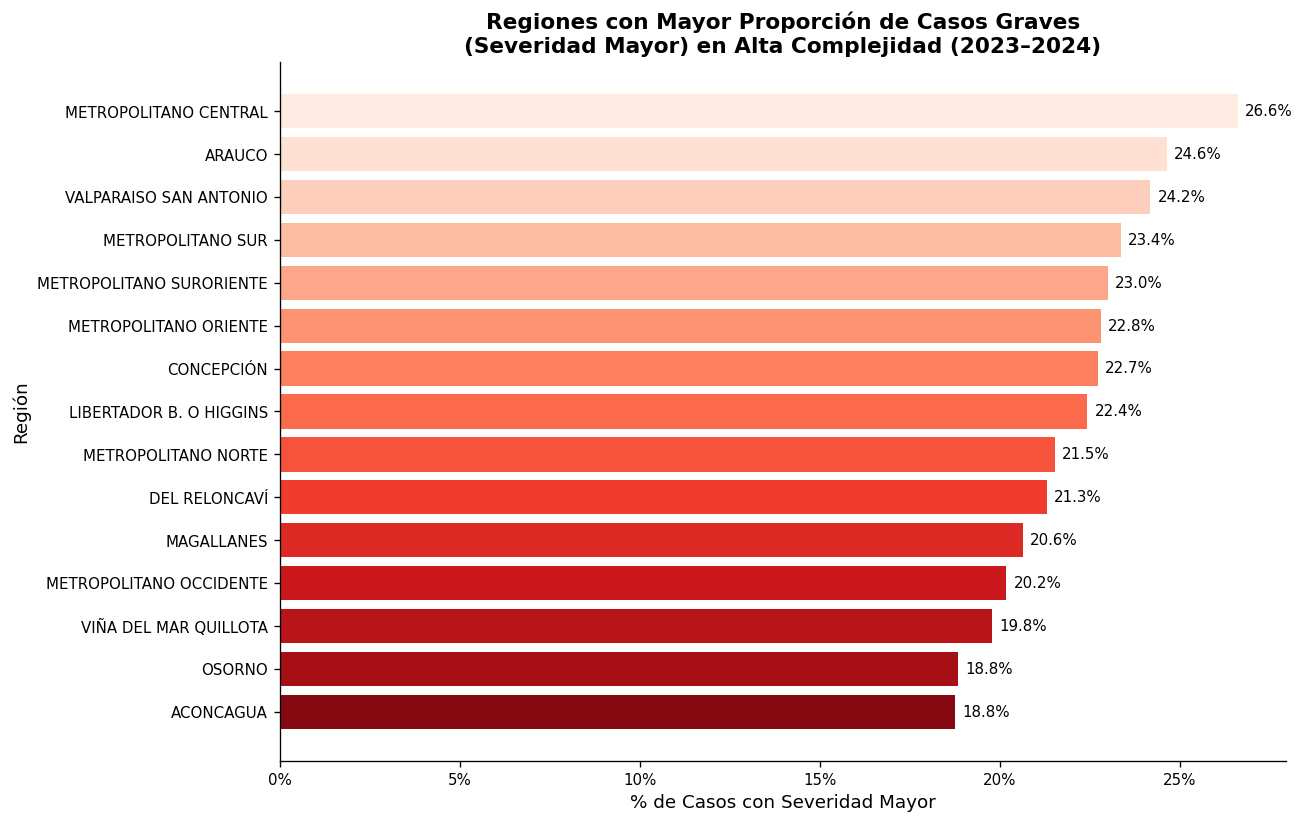

In [15]:
# ============================================================
# GRÁFICO 9: PROPORCIÓN DE CASOS GRAVES POR PROVINCIA (TOP 15)
# ============================================================
prop_graves = (
    GRD_ALTA.groupby('SERVICIO_SALUD')
    .agg(
        N_Total=('IR_29301_SEVERIDAD', 'count'),
        N_Graves=('IR_29301_SEVERIDAD', lambda x: (x == 3).sum())
    )
    .query('N_Total >= 1000')  # Solo regiones con suficientes datos
)
prop_graves['Prop_Graves'] = prop_graves['N_Graves'] / prop_graves['N_Total']
prop_graves = prop_graves.sort_values('Prop_Graves', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    prop_graves.index[::-1],
    prop_graves['Prop_Graves'].values[::-1] * 100,
    color=sns.color_palette('Reds_r', len(prop_graves))
)

for bar, val in zip(bars, prop_graves['Prop_Graves'].values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)

ax.set_title('Regiones con Mayor Proporción de Casos Graves\n(Severidad Mayor) en Alta Complejidad (2023–2024)',
             fontweight='bold')
ax.set_xlabel('% de Casos con Severidad Mayor')
ax.set_ylabel('Región')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### Identificación de Patrones: Evolución Mensual de Hospitalizaciones


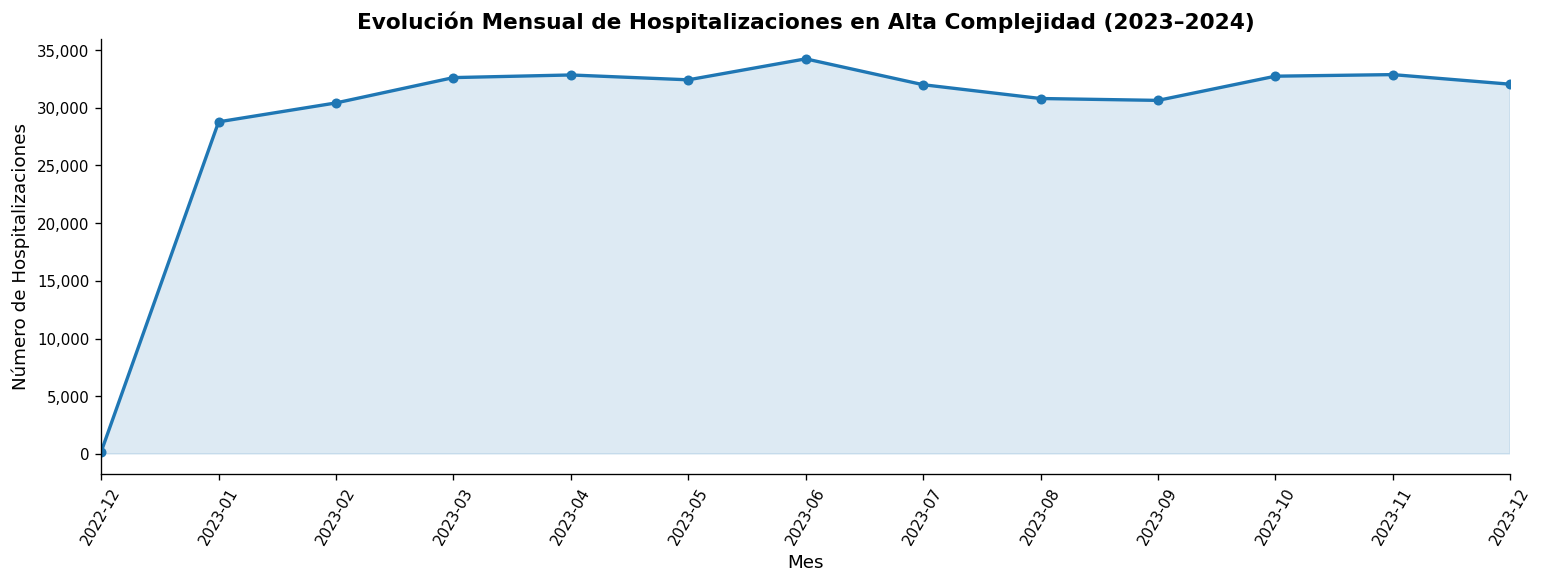

In [16]:
# ============================================================
# GRÁFICO 10: EVOLUCIÓN MENSUAL DE HOSPITALIZACIONES
# ============================================================

GRD_ALTA['ANIO_MES'] = GRD_ALTA['FECHA_INGRESO'].dt.to_period('M')
mensual = GRD_ALTA.groupby('ANIO_MES').size().reset_index(name='N_CASOS')
mensual = mensual.dropna()
mensual['ANIO_MES_STR'] = mensual['ANIO_MES'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(mensual['ANIO_MES_STR'], mensual['N_CASOS'],
        marker='o', markersize=5, color=COLOR_MAIN, linewidth=2)
ax.fill_between(mensual['ANIO_MES_STR'], mensual['N_CASOS'],
                alpha=0.15, color=COLOR_MAIN)
ax.set_title('Evolución Mensual de Hospitalizaciones en Alta Complejidad (2023–2024)',
                fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de Hospitalizaciones')
ax.tick_params(axis='x', rotation=60)
plt.xlim("2022-12", "2023-12")

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()






## Análisis Flujo de Pacientes por Regiones

In [17]:

# Tomamos RegionGlosa y RegionCodigo del dataset de establecimientos
est_region = establecimientosAlta[[
    'EstablecimientoCodigo', 'RegionGlosa', 'RegionCodigo'
]].drop_duplicates('EstablecimientoCodigo')

GRD_ALTA = GRD_ALTA.merge(
    est_region,
    left_on='COD_HOSPITAL', right_on='EstablecimientoCodigo',
    how='left'
).drop(columns=['EstablecimientoCodigo'])


# Limpieza de nombres para comparación
GRD_ALTA['REGION_HOSPITAL'] = GRD_ALTA['RegionGlosa'].str.strip().str.upper()

# Mapeamos la región del paciente desde SERVICIO_SALUD (texto libre)
# usando la provincia como una segunda opción

GRD_ALTA['PROVINCIA_PAC'] = GRD_ALTA['PROVINCIA'].str.strip().str.upper()

# Determinamos si el paciente es foráneo:

# La lógica es: si la region del paciente no pertenece a la región del hospital
# mMapeo provincia a región:

provincia_a_region = (
    GRD_ALTA[GRD_ALTA['REGION_HOSPITAL'].notna()]
    .groupby('PROVINCIA_PAC')['REGION_HOSPITAL']
    .agg(lambda x: x.mode()[0] if len(x) > 0 else None)  # región más frecuente por provincia
    .reset_index()
    .rename(columns={'REGION_HOSPITAL': 'REGION_ESPERADA_PAC'})
)

GRD_ALTA = GRD_ALTA.merge(provincia_a_region, on='PROVINCIA_PAC', how='left')

# Paciente foráneo = atendido en una región distinta a su región esperada
GRD_ALTA['FORANEO'] = (
    GRD_ALTA['REGION_HOSPITAL'].notna() &
    GRD_ALTA['REGION_ESPERADA_PAC'].notna() &
    (GRD_ALTA['REGION_HOSPITAL'] != GRD_ALTA['REGION_ESPERADA_PAC'])
)

total = GRD_ALTA['FORANEO'].notna().sum()
foraneos = GRD_ALTA['FORANEO'].sum()
print(f'Total registros con región identificada: {total:,}')
print(f'Pacientes foráneos (atendidos fuera de su región): {foraneos:,} ({foraneos/total:.1%})')
print(f'Pacientes locales (atendidos en su propia región): {total-foraneos:,} ({(total-foraneos)/total:.1%})')


# Mostrar Regiones unicas en hospital y región esperada
regiones_hospital = GRD_ALTA['REGION_HOSPITAL'].dropna().unique()
regiones_esperada = GRD_ALTA['REGION_ESPERADA_PAC'].dropna().unique()
print(f'Regiones de hospitales: {regiones_hospital}')
print(f'Regiones esperadas de pacientes: {regiones_esperada}')


Total registros con región identificada: 1,987,858
Pacientes foráneos (atendidos fuera de su región): 42,112 (2.1%)
Pacientes locales (atendidos en su propia región): 1,945,746 (97.9%)
Regiones de hospitales: ['REGIÓN DE LOS RÍOS' 'REGIÓN METROPOLITANA DE SANTIAGO'
 'REGIÓN DE VALPARAÍSO' 'REGIÓN DE COQUIMBO' 'REGIÓN DE LOS LAGOS'
 'REGIÓN DEL MAULE' "REGIÓN DEL LIBERTADOR GRAL. B. O'HIGGINS"
 'REGIÓN DE LA ARAUCANÍA' 'REGIÓN DEL BÍOBÍO' 'REGIÓN DE TARAPACÁ'
 'REGIÓN DE ANTOFAGASTA' 'REGIÓN DE ARICA PARINACOTA' 'REGIÓN DE ÑUBLE'
 'REGIÓN DE ATACAMA' 'REGIÓN DE AYSÉN DEL GENERAL CARLOS IBAÑEZ DEL CAMPO'
 'REGIÓN DE MAGALLANES Y DE LA ANTÁRTICA CHILENA']
Regiones esperadas de pacientes: ['REGIÓN DE LOS RÍOS' 'REGIÓN METROPOLITANA DE SANTIAGO'
 'REGIÓN DE VALPARAÍSO' 'REGIÓN DE COQUIMBO' 'REGIÓN DE LOS LAGOS'
 'REGIÓN DEL MAULE' "REGIÓN DEL LIBERTADOR GRAL. B. O'HIGGINS"
 'REGIÓN DE LA ARAUCANÍA' 'REGIÓN DEL BÍOBÍO' 'REGIÓN DE TARAPACÁ'
 'REGIÓN DE ANTOFAGASTA' 'REGIÓN DE ARICA PARINACOTA



### Fuentes de Datos
- FONASA – GRD 2023: https://public.tableau.com/views/PropuestaTableroGRD/PropuestaTableroGRD?%3AshowVizHome=no#1
- FONASA – GRD 2024: https://public.tableau.com/views/PropuestaTableroGRD/PropuestaTableroGRD?%3AshowVizHome=no#1
- Ministerio de Salud – Establecimientos de Salud

